# 📈 Módulo 01: Machine Learning Estadístico & Optimización Convexa
## Capítulo 1: Del Perceptrón al Descenso de Gradiente y Regresión Logística

> *"En optimización combinatoria clásica buscamos entre estados discretos. En optimización continua convexa, la física del gradiente nos garantiza que rodar cuesta abajo conduce siempre al mejor estado posible."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/01_classical_ml/01_gradient_descent_and_linear_models.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías científicas y fijamos semillas para reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch scikit-learn
import time
from typing import Tuple, List
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para Machine Learning y Optimización Convexa")

✅ Entorno listo para Machine Learning y Optimización Convexa


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El nacimiento de la IA biológica: El Perceptrón de Rosenblatt (1958)
En 1958, el psicólogo de la Universidad de Cornell **Frank Rosenblatt** presentó al mundo el **Perceptrón**. No era solo un algoritmo: era una máquina física (el *Mark I Perceptron*) conectada a una matriz de $20 \times 20$ fotocélulas que simulaba una retina artificial.

La prensa de la época enloqueció. El *New York Times* escribió en portada:
> *"El embrión de un ordenador electrónico que la Marina espera que sea capaz de caminar, hablar, ver, escribir, reproducirse y ser consciente de su propia existencia."*

El algoritmo de actualización del perceptrón era discreto y simple: si se equivocaba en una muestra binaria, sumaba o restaba el vector de entrada a los pesos:
$$w \leftarrow w + \eta (y - \hat{y}) x$$

### El golpe demoledor de Minsky & Papert (1969) y el Primer Invierno de la IA
En 1969, dos de las figuras más influyentes del MIT, **Marvin Minsky** (uno de los fundadores del campo de la IA) y **Seymour Papert**, publicaron el libro *Perceptrons*.

En él demostraron rigurosamente una limitación geométrica fatal: **un clasificador lineal es matemáticamente incapaz de resolver el problema del XOR (o-exclusivo)**. Como dos puntos de la misma clase están en diagonal en un plano 2D, ninguna línea recta puede separarlos.

Minsky y Papert conjeturaron además que extender estas redes a múltiples capas sería computacionalmente inviable de entrenar. Las consecuencias fueron devastadoras: **la financiación pública y militar se canceló casi por completo**, sumergiendo a la investigación de redes neuronales en el llamado **Primer Invierno de la IA** durante más de una década.

### El rescate: La Optimización Continua y el Aprendizaje Estadístico
¿Por qué falló el perceptrón original? Porque su función de activación era un escalón discreto (cero o uno), cuya derivada es cero en todas partes. Era imposible saber si un pequeño cambio de pesos mejoraba o empeoraba la solución.

La comunidad aprendió la lección recurriendo a herramientas de la estadística y el análisis numérico continuo:
1. Sustituir funciones escalón por **curvas suaves y diferenciables** (como la función sigmoide desarrollada por **David Cox en 1958** para la Regresión Logística).
2. Formular funciones de pérdida **convexas** (Mean Squared Error y Binary Cross-Entropy).
3. Reemplazar la búsqueda heurística por **Descenso de Gradiente**, garantizando la convergencia matemática hacia el óptimo global.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### Optimización Combinatoria vs Optimización Continua
Como programadores, estamos acostumbrados a la optimización combinatoria:
* Encontrar el camino más corto en un grafo discreto (Dijkstra, $A^*$).
* Encontrar la mejor combinación de elementos en una mochila (Programación Dinámica o Branch & Bound).

En esos problemas, el espacio de búsqueda consiste en nodos o permutaciones discretas. Si cambiamos un parámetro en un valor infinitesimal, la solución da un salto cualitativo.

En **optimización continua**, el espacio de parámetros es un campo suave $\mathbb{R}^d$:
* Cada punto en el espacio tiene una altitud dada por la función de pérdida $\mathcal{L}(w)$.
* El gradiente $\nabla \mathcal{L}(w)$ es un vector que apunta exactamente en la **dirección de máxima pendiente hacia arriba**.
* Por tanto, moverse en la dirección opuesta ($-\nabla \mathcal{L}(w)$) nos garantiza dar el paso de mayor descenso local.

### La Propiedad de la Convexidad: El Sueño de un Algoritmista
Una función es **convexa** si el segmento que une dos puntos cualesquiera de su gráfica queda por encima de la curva.

> **Teorema Fundamental:** En una función convexa diferenciable, **todo mínimo local es también el mínimo global único**. No existen trampas, ni valles falsos, ni necesidad de backtracking.

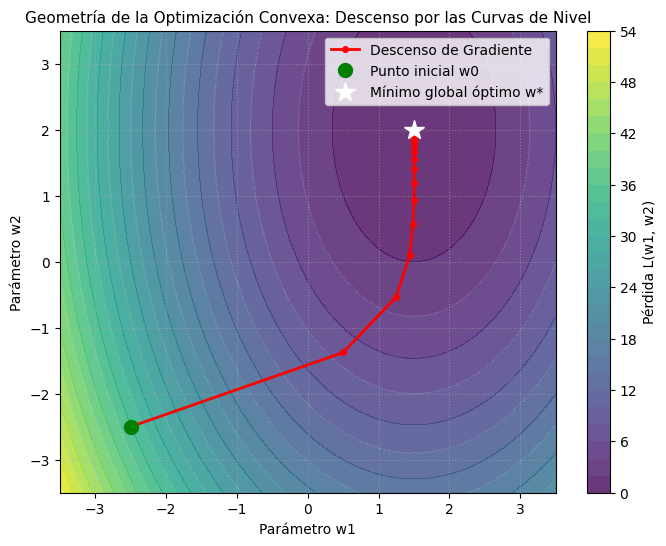

In [2]:
# Visualicemos el paisaje convexo y el descenso de gradiente
def loss_landscape(w1, w2):
    # Paraboloide elíptico (típico de Regresión Lineal con MSE)
    return 1.5 * (w1 - 1.5)**2 + 0.5 * (w2 - 2.0)**2

def grad_loss(w1, w2):
    return np.array([3.0 * (w1 - 1.5), 1.0 * (w2 - 2.0)])

# Simular descenso de gradiente desde un punto lejano
w_current = np.array([-2.5, -2.5])
lr = 0.25
trajectory = [w_current.copy()]

for _ in range(25):
    grad = grad_loss(w_current[0], w_current[1])
    w_current = w_current - lr * grad
    trajectory.append(w_current.copy())
trajectory = np.array(trajectory)

# Generar gráfico de contorno
w1_vals = np.linspace(-3.5, 3.5, 100)
w2_vals = np.linspace(-3.5, 3.5, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = loss_landscape(W1, W2)

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(W1, W2, Z, levels=30, cmap='viridis', alpha=0.8)
ax.contour(W1, W2, Z, levels=15, colors='white', alpha=0.3, linewidths=0.7)
fig.colorbar(cp, label='Pérdida L(w1, w2)')

ax.plot(trajectory[:, 0], trajectory[:, 1], 'r.-', linewidth=2, markersize=8, label='Descenso de Gradiente')
ax.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=10, label='Punto inicial w0')
ax.plot(1.5, 2.0, 'w*', markersize=15, label='Mínimo global óptimo w*')

ax.set_title("Geometría de la Optimización Convexa: Descenso por las Curvas de Nivel", fontsize=11)
ax.set_xlabel("Parámetro w1")
ax.set_ylabel("Parámetro w2")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()

### El Efecto de la Tasa de Aprendizaje (Learning Rate $\eta$)
¿Qué ocurre si la tasa de aprendizaje es inadecuada?
* **Muy pequeña (ej. 0.01):** El modelo tarda miles de pasos en avanzar.
* **Moderada / Óptima (ej. 0.25):** Descenso rápido y suave.
* **Demasiado grande (ej. 0.75):** Oscila salvajemente entre las paredes del valle.
* **Catastrófica (ej. 1.1):** El gradiente salta más allá del valle opuesto; la pérdida crece exponencialmente hasta producir `inf` o `NaN`.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

### A. Regresión Lineal: Forma Cerrada vs Descenso de Gradiente

Modelo: $\hat{y} = X w + b$

Función de Pérdida (Mean Squared Error - MSE):
$$\mathcal{L}(w) = \frac{1}{2m} \|X w - y\|^2_2$$

#### 1. Solución Analítica en Forma Cerrada (La Ecuación Normal)
Igualando el gradiente analítico a cero:
$$\nabla_w \mathcal{L} = \frac{1}{m} X^T (X w - y) = 0 \implies X^T X w = X^T y \implies \mathbf{w^* = (X^T X)^{-1} X^T y}$$

* **Complejidad algorítmica:** Invertir una matriz $d \times d$ tiene una complejidad de $O(d^3)$ (o $O(d^{2.81})$ con Strassen). Si tenemos 50.000 características, calcular $(X^T X)^{-1}$ es prohibitivo en memoria y tiempo.

#### 2. Solución Iterativa (Descenso de Gradiente)
$$w \leftarrow w - \eta \cdot \frac{1}{m} X^T (X w - y)$$
* **Complejidad:** $O(m \cdot d)$ por iteración. Extremadamente escalable y paralelizable en hardware vectorial.

In [3]:
class LinearRegressionFromScratch:
    """
    Regresión Lineal pura en NumPy con Ecuación Normal y Descenso de Gradiente.
    """
    def __init__(self, lr: float = 0.01, n_iterations: int = 1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    def fit_normal_equation(self, X: np.ndarray, y: np.ndarray):
        """Resuelve w* = (X_aug^T @ X_aug)^(-1) @ X_aug^T @ y en forma cerrada."""
        m, d = X.shape
        # Añadir columna de unos para el sesgo (bias)
        X_aug = np.hstack([np.ones((m, 1)), X])
        # Resolver el sistema lineal de mínimos cuadrados sin invertir explícitamente
        w_optimal = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
        self.bias = w_optimal[0]
        self.weights = w_optimal[1:]
        return self

    def fit_gradient_descent(self, X: np.ndarray, y: np.ndarray):
        """Optimiza pesos iterativamente mediante Descenso de Gradiente."""
        m, d = X.shape
        self.weights = np.zeros(d)
        self.bias = 0.0
        self.loss_history = []

        for i in range(self.n_iterations):
            # 1. Forward pass (predicción)
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            
            # 2. Función de coste (MSE)
            mse = (1.0 / (2 * m)) * np.sum(error ** 2)
            self.loss_history.append(mse)
            
            # 3. Gradientes analíticos
            grad_w = (1.0 / m) * (X.T @ error)
            grad_b = (1.0 / m) * np.sum(error)
            
            # 4. Actualización de parámetros
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b
            
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias

print("✅ LinearRegressionFromScratch definida correctamente")

✅ LinearRegressionFromScratch definida correctamente


### Demostración: Comparativa de Ecuación Normal vs Descenso de Gradiente

Solución Ecuación Normal:   w = 2.9805, b = 4.0526
Solución Descenso Gradiente: w = 2.9857, b = 4.0465


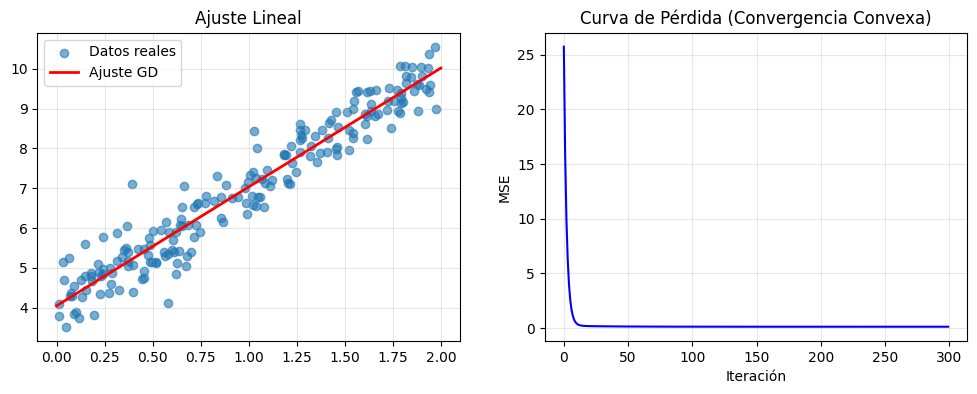

In [4]:
# Generar dataset sintético con ruido
np.random.seed(42)
X_demo = 2 * np.random.rand(200, 1)
y_demo = 4 + 3 * X_demo[:, 0] + np.random.randn(200) * 0.5

# 1. Ajuste con Ecuación Normal
model_norm = LinearRegressionFromScratch().fit_normal_equation(X_demo, y_demo)
print(f"Solución Ecuación Normal:   w = {model_norm.weights[0]:.4f}, b = {model_norm.bias:.4f}")

# 2. Ajuste con Descenso de Gradiente
model_gd = LinearRegressionFromScratch(lr=0.1, n_iterations=300).fit_gradient_descent(X_demo, y_demo)
print(f"Solución Descenso Gradiente: w = {model_gd.weights[0]:.4f}, b = {model_gd.bias:.4f}")

# Gráfica de ajuste
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(X_demo, y_demo, alpha=0.6, label='Datos reales')
x_line = np.linspace(0, 2, 100).reshape(-1, 1)
ax1.plot(x_line, model_gd.predict(x_line), 'r-', linewidth=2, label='Ajuste GD')
ax1.set_title("Ajuste Lineal")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(model_gd.loss_history, 'b-', linewidth=1.5)
ax2.set_title("Curva de Pérdida (Convergencia Convexa)")
ax2.set_xlabel("Iteración")
ax2.set_ylabel("MSE")
ax2.grid(True, alpha=0.3)
plt.show()

### B. Regresión Logística y la Pérdida de Entropía Cruzada (BCE)

Para clasificación binaria ($y \in \{0, 1\}$), transformamos la salida lineal mediante la función **Sigmoide**:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

#### ¿Por qué el MSE falla en clasificación binaria?
Si usamos MSE con una sigmoide, la función de pérdida resultante **deja de ser convexa**: crea mesetas horizontales donde el gradiente se aproxima a cero en predicciones erróneas saturadas, atascando al optimizador.

La solución matemática es la **Entropía Cruzada Binaria (Binary Cross-Entropy)**:
$$\mathcal{L}(w, b) = -\frac{1}{m} \sum_{i=1}^m \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

#### La belleza del gradiente de BCE
Aunque la fórmula de la pérdida parece compleja, al derivar $\frac{\partial \mathcal{L}}{\partial w}$ ocurre una simplificación milagrosa:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

¡Tiene exactamente la misma forma que el gradiente de la regresión lineal! La única diferencia es que $\hat{y} = \sigma(X w + b)$.

In [5]:
class LogisticRegressionFromScratch:
    """
    Regresión Logística pura en NumPy con Binary Cross-Entropy numéricamente estable.
    """
    def __init__(self, lr: float = 0.1, n_iterations: int = 1000):
        self.lr = lr
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0.0
        self.loss_history = []

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        # Implementación numéricamente estable para evitar overflow en exp(-z)
        return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, d = X.shape
        self.weights = np.zeros(d)
        self.bias = 0.0
        self.loss_history = []
        eps = 1e-15  # Protección para evitar log(0)

        for _ in range(self.n_iterations):
            # 1. Forward
            z = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)
            
            # 2. Binary Cross-Entropy Loss
            y_hat_safe = np.clip(y_hat, eps, 1.0 - eps)
            loss = -np.mean(y * np.log(y_hat_safe) + (1.0 - y) * np.log(1.0 - y_hat_safe))
            self.loss_history.append(loss)
            
            # 3. Gradiente analítico
            error = y_hat - y
            grad_w = (1.0 / m) * (X.T @ error)
            grad_b = np.mean(error)
            
            # 4. Paso de gradiente
            self.weights -= self.lr * grad_w
            self.bias -= self.lr * grad_b
            
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

print("✅ LogisticRegressionFromScratch definida correctamente")

✅ LogisticRegressionFromScratch definida correctamente


---

## 4. ⚡ Transición a PyTorch Moderno

### El Detalle de Producción: `BCEWithLogitsLoss`
En PyTorch, los desarrolladores novatos a menudo usan `nn.Sigmoid()` seguido de `nn.BCELoss()`. Esto es una mala práctica porque:
1. Introduce dos pasos numéricos separados donde los flotantes pequeños se aproximan a cero.
2. `nn.BCEWithLogitsLoss()` fusiona la sigmoide y el logaritmo mediante el truco matemático **Log-Sum-Exp**, alcanzando la máxima estabilidad numérica frente a desbordamientos en precisión FP16 o FP32.

In [6]:
# Clasificación en PyTorch idiomático
class LogisticRegressionPyTorch(nn.Module):
    def __init__(self, in_features: int):
        super().__init__()
        # Una regresión logística es simplemente una capa lineal de 1 salida
        self.linear = nn.Linear(in_features, 1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Retornamos los LOGITS directos (sin sigmoide) para alimentar a BCEWithLogitsLoss
        return self.linear(x)

# Generar datos de clasificación 2D separables
np.random.seed(42)
X_class = np.random.randn(200, 2)
y_class = ((X_class[:, 0] * 1.5 + X_class[:, 1] * -2.0 + 0.5) > 0).astype(np.float32)

# Entrenamiento en PyTorch
t_X = torch.from_numpy(X_class.astype(np.float32))
t_y = torch.from_numpy(y_class).unsqueeze(1)

torch_model = LogisticRegressionPyTorch(in_features=2)
criterion = nn.BCEWithLogitsLoss()  # Combina Sigmoid + BCE con Log-Sum-Exp
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.5)

for epoch in range(200):
    optimizer.zero_grad()
    logits = torch_model(t_X)
    loss = criterion(logits, t_y)
    loss.backward()
    optimizer.step()

print("Pesos en PyTorch: ", torch_model.linear.weight.data.numpy().flatten())
print("Bias en PyTorch:  ", torch_model.linear.bias.data.item())

# Comparar con nuestro modelo from-scratch
fs_model = LogisticRegressionFromScratch(lr=0.5, n_iterations=200).fit(X_class, y_class)
print("Pesos From-Scratch:", fs_model.weights)
print("Bias From-Scratch: ", fs_model.bias)

Pesos en PyTorch:  [ 3.3937137 -4.096751 ]
Bias en PyTorch:   1.0101484060287476
Pesos From-Scratch: [ 3.39650501 -4.10040341]
Bias From-Scratch:  1.0111152618491261


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: El Asesinato del Perceptrón (El Problema XOR de Minsky)
Vamos a reproducir exactamente el experimento de Minsky & Papert (1969):
1. Entrenar la regresión logística en los 4 puntos de la tabla de verdad de XOR.
2. Visualizar la frontera de decisión lineal y constatar que es imposible superar el 50-75% de precisión.
3. **El truco de ingeniería algorítmica:** Añadir una característica no lineal sintética (ej. $x_1 \cdot x_2$) y observar cómo la frontera lineal en el espacio transformado resuelve perfectamente el XOR con 100% de precisión.

In [7]:
# Tabla de verdad XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([0, 1, 1, 0], dtype=np.float32)

# 1. Intentar separar XOR linealmente (Minsky 1969)
xor_linear = LogisticRegressionFromScratch(lr=1.0, n_iterations=500).fit(X_xor, y_xor)
preds_linear = xor_linear.predict(X_xor)
print(f"Predicciones XOR con características lineales [x1, x2]: {preds_linear} | Reales: {y_xor.astype(int)}")
print(f"Precisión lineal: {np.mean(preds_linear == y_xor) * 100:.0f}%")

# 2. Ingeniería de Características (Feature Engineering: agregando x1 * x2)
x_interaccion = (X_xor[:, 0] * X_xor[:, 1]).reshape(-1, 1)
X_xor_augmented = np.hstack([X_xor, x_interaccion])

xor_augmented = LogisticRegressionFromScratch(lr=1.0, n_iterations=500).fit(X_xor_augmented, y_xor)
preds_aug = xor_augmented.predict(X_xor_augmented)
print(f"Predicciones XOR con dimensión aumentada [x1, x2, x1*x2]: {preds_aug} | Reales: {y_xor.astype(int)}")
print(f"Precisión con característica no lineal: {np.mean(preds_aug == y_xor) * 100:.0f}% 🚀")

Predicciones XOR con características lineales [x1, x2]: [1 1 1 1] | Reales: [0 1 1 0]
Precisión lineal: 50%
Predicciones XOR con dimensión aumentada [x1, x2, x1*x2]: [0 1 1 0] | Reales: [0 1 1 0]
Precisión con característica no lineal: 100% 🚀


### Reto 2 (Para resolver): Diagnosticar la Inestabilidad Numérica
Considera la siguiente función ingenua de BCE sin protección de clipping:
```python
def bce_naive(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
```
Si un modelo predice con absoluta certeza $y_{pred} = 1.0$ pero la etiqueta real es $y_{true} = 0$, $\log(1 - 1.0) = \log(0) = -\infty$, produciendo `NaN`.

Implementa a continuación una función `bce_from_logits(y_true, z)` que reciba directamente los logits $z$ (donde $\hat{y} = \sigma(z)$) y calcule la pérdida usando la formulación analítica estable:

In [8]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def stable_bce_from_logits(y_true: np.ndarray, z: np.ndarray) -> float:
    """
    Calcula BCE directamente desde logits usando la identidad:
    loss = max(z, 0) - z * y + log(1 + exp(-abs(z)))
    """
    # Implementar y retornar la pérdida escalar
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Rosenblatt, F. (1958):** *"The perceptron: A probabilistic model for information storage and organization in the brain"*, Psychological Review, 65(6), 386-408. [DOI: 10.1037/h0042519](https://doi.org/10.1037/h0042519)
   * *¿Qué leer?* La introducción y la regla de aprendizaje de pesos original.
2. **Minsky, M., & Papert, S. (1969):** *"Perceptrons: An Introduction to Computational Geometry"*, MIT Press.
   * *¿Qué leer?* Capítulo 1 ("Linear Separability") y el análisis de la función de paridad/XOR.
3. **Cox, D. R. (1958):** *"The Regression Analysis of Binary Sequences"*, Journal of the Royal Statistical Society, 20(2), 215-242.
   * *¿Qué leer?* La introducción del modelo logístico y el concepto de log-odds.

### 🔗 Libros de Referencia en Optimización
* **Stephen Boyd & Lieven Vandenberghe:** *Convex Optimization* (Cambridge University Press, 2004) - El texto definitivo sobre geometría y algoritmos de optimización convexa ([Descarga gratuita oficial](https://web.stanford.edu/~boyd/cvxbook/)).
* **Sebastian Ruder:** *An overview of gradient descent optimization algorithms* (2016) - Excelente resumen de dinámicas de gradiente.